---
header-includes:
  - \usepackage{braket}
---
# Qubit Dynamics Under Hamiltonians 
### Time Evolution, Expectation Values, and Larmor Precession

In this notebook, we study the dynamics of a single qubit evolving under a Hamiltonian proportional to the Pauli matrices.  
This is the simplest non‑trivial example of qubit time evolution, and it plays a central role in quantum information and spin physics.

A Hamiltonian of the form  


$$
H = \frac{\hbar\omega}{2}\sigma_z
$$

  
generates a rotation of the Bloch vector around the **z‑axis** with angular frequency $\omega$.  
This corresponds physically to **Larmor precession**, the fundamental motion of a spin‑½ particle in a static magnetic field.

We will:

- define the initial state and Pauli matrices  
- compute the exact time evolution analytically (using the diagonal structure of $\sigma_z$)  
- evaluate the expectation value $\braket{\sigma_x}$ (t)  
- verify probability conservation  
- plot the resulting oscillations  

This notebook is the computational counterpart of the theoretical results derived in Chapter 09.


In [9]:
import numpy as np
from utils import *

# Define the standard basis vectors

ket_0=np.array([[1],
               [0]], dtype=complex)

ket_1=np.array([[0],
               [1]], dtype=complex)

psi_0=(1/np.sqrt(2))*np.array([[1],
                               [np.sqrt(2)]], dtype=complex)

# Define the Pauli matrices

sigma_x=np.array([[0,1],
                 [1,0]], dtype=complex)
sigma_y=np.array([[0, 0-1.j],
                  [0+1.j,0]], dtype=complex)
sigma_z=np.array([[1,0],
                 [0,-1]], dtype=complex)

# Define an Hamiltonian proportional to sigma_z (fixing h=1)
omega=float(1)
H=(omega/2)*sigma_z

# Define the Unitary transformation
# First timeline
t=np.linspace(0,10,500)

#Hamiltonian is proprtional to sigma_z, so it's diagonal which means that exponential of the matrice equal matrice of exponentials 
# defining exponential of eigenvalues
E1=omega*0.5
E2=omega*-0.5

#Create the composants of U(t) matrice for each value of t
# So Numpy will broadcast the calculus over t table
u11=np.exp(-1.j*E1*t)
u22=np.exp(-1.j*E2*t)

# It's not easy to stock 500 matrice 2x2 in an array then do kets multiplication
# the simplest for psi evolution is:
psi_t=np.array([u11*psi_0[0,0],
                u22*psi_0[1,0]])

# psi_t will have a (2,500) form: each colomn is the state at t.

# psi_t.conj() give the bra (conjugat complex)
# We calculate for all t at once:

exp_x = np.sum(psi_t.conj() * (sigma_x @ psi_t), axis=0).real

# Total probability : |psi_1|^2 + |psi_2|^2

# prob_totale should be an array of 500 of value 1.0

prob_totale = np.abs(psi_t[0])**2 + np.abs(psi_t[1])**2

print(prob_totale[:5]) # Show 5 first points 


[1.5 1.5 1.5 1.5 1.5]


---
header-includes:
  - \usepackage{braket}
---
## Time Evolution Under a $\sigma_z$ Hamiltonian

We begin by defining the computational basis states $\ket0$ and $\ket1$, the Pauli matrices, and the initial state:


$$\ket{\psi(0)} = \frac{1}{\sqrt{2}}(\ket0 + \ket1),$$


which corresponds to a Bloch vector initially aligned along the **x‑axis**.

We choose a Hamiltonian proportional to $\sigma_z$:


$$H = \frac{\omega}{2}\sigma_z.$$


Since σ_z is diagonal, its exponential is extremely simple:


$$e^{-iHt} = 
\begin{pmatrix}
e^{-i\omega t/2} & 0 \\
0 & e^{+i\omega t/2}
\end{pmatrix}.$$



This means that the two components of the spinor acquire **opposite phases**.  
There is **no population transfer** between $\ket0$ and $\ket1$ — only a **relative phase evolution**, which corresponds to a rotation around the z‑axis on the Bloch sphere.

We compute the evolved state $\psi(t)$ for 500 time points, and then evaluate:

- the expectation value  
  


  $$\langle\sigma_x\rangle(t) = \psi(t)^\dagger \sigma_x \psi(t)$$


- the total probability  
  

  $$|\psi_0(t)|^2 + |\psi_1(t)|^2 = 1$$



The probability check confirms that the evolution is unitary.


<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_21400\300287003.py:10: SyntaxWarning: invalid escape sequence '\s'
  plt.title("Lamor precession : $\sigma_x$ mean value's evolution", fontsize=14)


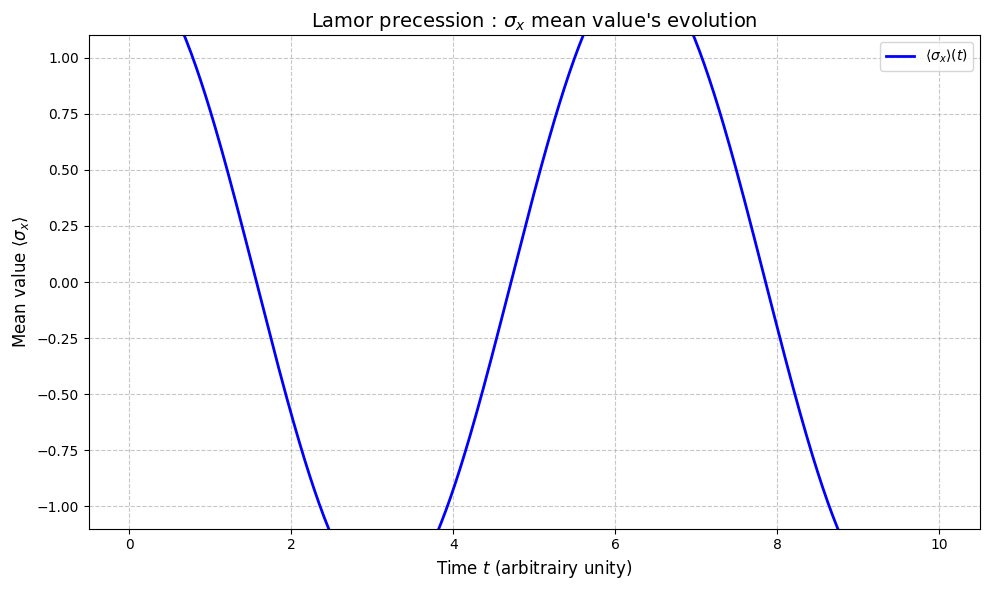

In [10]:
import matplotlib.pyplot as plt

# Configuration
plt.figure(figsize=(10, 6))

# plot mean value of sigma_x in function of time
plt.plot(t, exp_x, label=r'$\langle \sigma_x \rangle(t)$', color='blue', linewidth=2)

# Adds cosmetic details 
plt.title("Lamor precession : $\sigma_x$ mean value's evolution", fontsize=14)
plt.xlabel('Time $t$ (arbitrairy unity)', fontsize=12)
plt.ylabel(r'Mean value $\langle \sigma_x \rangle$', fontsize=12)

# We fix the limits of the Y axis, because a mean value of a spin is between -1 & 1
plt.ylim(-1.1, 1.1)

# Adds grid to make reading easier
plt.grid(True, linestyle='--', alpha=0.7)

# Adds the legend
plt.legend(loc='upper right')

# Graphic display
plt.tight_layout()
plt.savefig('larmor_precession.png')
plt.show()

---
header-includes:
  - \usepackage{braket}
---
## Plotting the Expectation Value $\braket{\sigma_x}(t)$

The expectation value $\braket{\sigma_x}(t)$ oscillates in time because the initial state is an eigenstate of $\sigma_x$, while the Hamiltonian generates a rotation around the z‑axis.

From the analytical solution:



$$\ket{\psi(t)} = 
\frac{1}{\sqrt{2}}
\begin{pmatrix}
e^{-i\omega t/2} \\
e^{+i\omega t/2}
\end{pmatrix},$$


we obtain:


$$\langle\sigma_x\rangle(t) = \cos(\omega t).$$



This is exactly what the plot shows: a **cosine oscillation** of amplitude 1.  
Physically, this is **Larmor precession**: the Bloch vector rotates in the equatorial plane, and its projection on the x‑axis oscillates.

The plot includes:

- axis labels  
- a fixed y‑range (since $\sigma_x$ $\in$ [−1, 1])  
- a grid for readability  
- a legend and a title  

The resulting figure clearly illustrates the periodic nature of the qubit dynamics under a $\sigma_z$ Hamiltonian.
______________

---
header-includes:
  - \usepackage{braket}
---
## Dynamics Under a $\sigma_x$ Hamiltonian  
### Rabi Oscillations and Population Transfer

In this section, we study the time evolution of a qubit under a Hamiltonian proportional to the Pauli matrix $\sigma_x$:




$$H_x = \frac{\Omega}{2}\sigma_x.$$



Unlike the $\sigma_z$ Hamiltonian, which only changes the **relative phase** between $\ket0$ and $\ket1$, the $\sigma_x$ Hamiltonian **couples** the two basis states:




$$\sigma_x \ket0 = \ket1 \quad , \quad
\sigma_x \ket1 = \ket0.$$



This leads to **Rabi oscillations**, where the population oscillates periodically between  $\ket0$ and $\ket1$ .

We will:

- compute the exact time evolution  
- evaluate the probability of being in |1⟩ as a function of time  
- compute the expectation value $\braket{\sigma_z} (t)$ 
- visualize the oscillatory behavior  

This is the fundamental mechanism behind qubit control in real quantum hardware.


In [11]:
import numpy as np

# Initial state: |ψ(0)> = |0>
# We choose |0> to clearly see population transfer to |1>
psi0 = ket_0.copy()

# Hamiltonian proportional to sigma_x
Omega = 1.0  # Rabi frequency
H_x = (Omega * 0.5) * sigma_x

t = np.linspace(0, 10, 500)

# Since sigma_x is NOT diagonal, we cannot exponentiate element-wise
# We use the analytical formula:
#   exp(-i θ σ_x) = cos(θ) I - i sin(θ) σ_x
# where θ = Omega * t / 2

theta = (Omega * t) / 2

# Compute cos(θ) and sin(θ) for all times
cos_t = np.cos(theta)
sin_t = np.sin(theta)

# Build U(t) for all times
# U(t) = cos(θ) I - i sin(θ) σ_x
# We construct psi(t) directly without storing all U(t) matrices

psi_t_x = np.zeros((2, len(t)), dtype=complex)

# Apply U(t) to |0>:
# |ψ(t)> = cos(θ)|0> - i sin(θ) σ_x|0>
# and σ_x|0> = |1>

psi_t_x[0] = cos_t * psi0[0,0]          # amplitude of |0>
psi_t_x[1] = -1j * sin_t * psi0[0,0]    # amplitude of |1>

# Compute expectation value of σ_z
# <σ_z>(t) = ψ† σ_z ψ
exp_z = np.sum(psi_t_x.conj() * (sigma_z @ psi_t_x), axis=0).real

# Compute probability of being in |1> 
P1 = np.abs(psi_t_x[1])**2

# Probability conservation check
prob_total_x = np.abs(psi_t_x[0])**2 + np.abs(psi_t_x[1])**2
print(prob_total_x[:5])  # should be all 1.0


[1. 1. 1. 1. 1.]


### Interpretation of the $\sigma_x$ Dynamics

The Hamiltonian


$$H = \frac{\omega}{2}\sigma_x$$

mixes the states $\ket0$ and $\ket1$ .  
This is fundamentally different from the $\sigma_z$ Hamiltonian, which only adds opposite phases.

Using the analytical identity:


$$e^{-i\theta\sigma_x}= \cos\theta\,I - i\sin\theta\,\sigma_x$$

we obtain the time‑evolved state:

$$\ket{\psi(t)}= \cos\left(\frac{\omega t}{2}\right)\ket0 - i\sin\left(\frac{\omega t}{2}\right)\ket1.$$

This leads to:

$$P_{0\to 1}(t)= \sin^2\left(\frac{\omega t}{2}\right)$$

which is the hallmark of **Rabi oscillations**.

Physically:

- the Bloch vector rotates around the **x‑axis**  
- the z‑component oscillates between +1 and −1  
- the qubit periodically transitions between $\ket0$ and $\ket1$  

This is the mechanism used in real quantum hardware to perform X‑gates and arbitrary rotations.


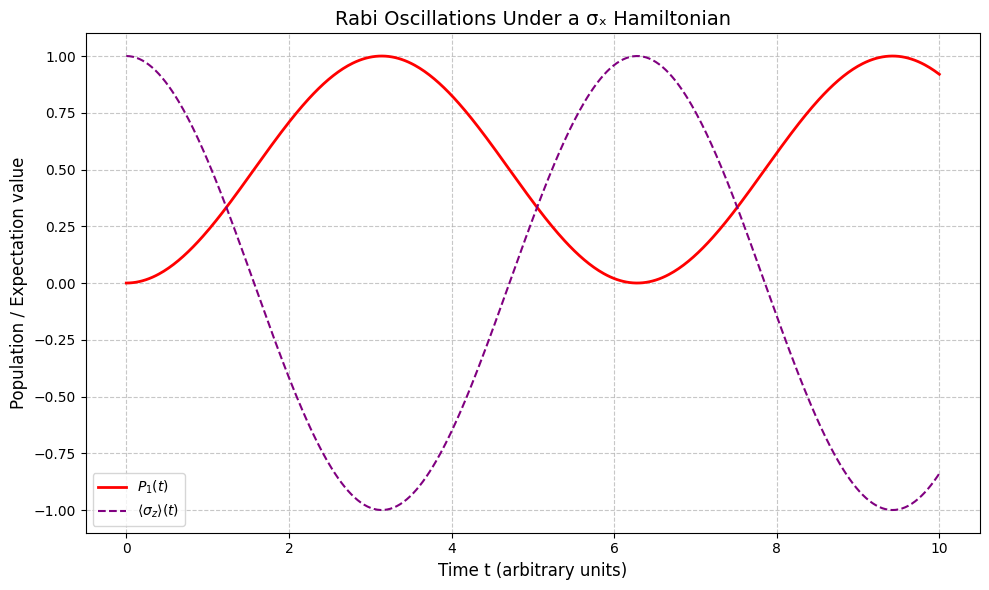

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Plot probability of being in |1>
plt.plot(t, P1, label=r'$P_{1}(t)$', color='red', linewidth=2)

# Plot expectation value of sigma_z
plt.plot(t, exp_z, label=r'$\langle \sigma_z \rangle(t)$', color='purple', linestyle='--')

plt.title("Rabi Oscillations Under a σₓ Hamiltonian", fontsize=14)
plt.xlabel("Time t (arbitrary units)", fontsize=12)
plt.ylabel("Population / Expectation value", fontsize=12)

plt.ylim(-1.1, 1.1)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.savefig("rabi_sigma_x.png")
plt.show()


### Summary

Under a $\sigma_x$ Hamiltonian:

- the qubit undergoes **Rabi oscillations**  
- population transfers periodically between $\ket0$ and $\ket1$  
- the Bloch vector rotates around the **x‑axis**  
- $\braket{\sigma_z}$(t) oscillates between +1 and −1  
- probability is conserved at all times  

This example complements the $\sigma_z$ case:  
$\sigma_z$ → phase evolution  
$\sigma_x$ → population oscillation  
